In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [22]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 40
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


In [23]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img       
        
        

In [24]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")
print("dataset shape:", full_train_dataset.x.shape)

Loading train data from ./processed_data\quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000
dataset shape: torch.Size([60000, 784])


In [26]:
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional


def move_to_device(x: torch.Tensor, y: Optional[torch.Tensor], device: torch.device):
    x = x.to(device, non_blocking=True)
    if y is not None:
        y = y.to(device, non_blocking=True)
    return x, y


@dataclass
class History:

    train_loss: List[float] = field(default_factory=list)
    train_acc: List[float] = field(default_factory=list)
    val_loss: List[float] = field(default_factory=list)
    val_acc: List[float] = field(default_factory=list)

    def as_dict(self) -> Dict[str, List[float]]:
        return {
            "train_loss": self.train_loss,
            "train_acc": self.train_acc,
            "val_loss": self.val_loss,
            "val_acc": self.val_acc,
        }


def train_one_epoch(
    model: torch.nn.Module,
    loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: torch.nn.Module,
    device: torch.device,
):
   
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for batch in loader:
        x, y = batch
        x, y = move_to_device(x, y, device)
        
        x = x + 0.01 * torch.randn_like(x)
        x = x.clamp(0.0, 1.0)

        logits = model(x)
        loss = loss_fn(logits, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)
        running_correct += (preds == y).sum().item()
        running_total += batch_size

    avg_loss = running_loss / max(running_total, 1)
    avg_acc = running_correct / max(running_total, 1)
    return avg_loss, avg_acc


@torch.no_grad()
def validate_one_epoch(
    model: torch.nn.Module,
    loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    device: torch.device,
):
   
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for batch in loader:
        x, y = batch
        x, y = move_to_device(x, y, device)
        

        logits = model(x)
        loss = loss_fn(logits, y)

        batch_size = y.size(0)
        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)
        running_correct += (preds == y).sum().item()
        running_total += batch_size

    avg_loss = running_loss / max(running_total, 1)
    avg_acc = running_correct / max(running_total, 1)
    return avg_loss, avg_acc

In [27]:
from typing import List


class MLPClassifier(nn.Module):
    def __init__(
        self,
        input_dim: int = 784,
        num_classes: int = 15,
        hidden_dims: List[int] = None,
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
        use_layernorm: bool = False,
    ):
        super().__init__()


        if hidden_dims is None:
            hidden_dims = []

        act = activation.lower()
        if act == "relu":
            activation_layer = nn.ReLU()
        elif act == "leakyrelu":
            activation_layer = nn.LeakyReLU(negative_slope=0.01)
        elif act == "gelu":
            activation_layer = nn.GELU()
        else:
            raise ValueError(f"Unsupported activation: {activation}")


        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            #  linear layer
            layers.append(nn.Linear(prev_dim, h))

            # normalization
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            if use_layernorm:
                layers.append(nn.LayerNorm(h))

            # nonlinearity
            layers.append(activation_layer)

            # dropout
            if dropout_p > 0.0:
                layers.append(nn.Dropout(p=dropout_p))
       
            prev_dim = h

        self.features = nn.Sequential(*layers)


        self.classifier = nn.Linear(prev_dim, num_classes)

    def forward(self, x: torch.Tensor):

        x = self.features(x)
        logits = self.classifier(x)
        return logits




In [28]:
pancake_model = MLPClassifier(
    input_dim=784,
    num_classes=15,
    hidden_dims=[1024, 512],
    activation="relu",
    dropout_p=0.2,
    use_batchnorm=False,
    use_layernorm=False,
)


tower_model = MLPClassifier(
    input_dim=784,
    num_classes=15,
    hidden_dims=[256, 256, 256, 256, 256, 256],
    activation="relu",
    dropout_p=0.0,
    use_batchnorm=True,
    use_layernorm=False,
)



In [30]:
import copy
from typing import Optional, Any


def _get_current_lr(optimizer: torch.optim.Optimizer) -> float:
    return optimizer.param_groups[0].get("lr", float("nan"))


def fit(
    model: torch.nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: torch.nn.Module,
    device: torch.device,
    epochs: int,
    scheduler: Optional[Any] = None,
    scheduler_step_on: str = "epoch",
    verbose: bool = True,
    log_every: int = 1,  
):
    model = model.to(device)

    history = History()
    best = {
        "epoch": -1,
        "val_acc": -1.0,
        "val_loss": float("inf"),
        "state_dict": None,
    }

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, val_acc = validate_one_epoch(model, val_loader, loss_fn, device)

        history.train_loss.append(train_loss)
        history.train_acc.append(train_acc)
        history.val_loss.append(val_loss)
        history.val_acc.append(val_acc)

        
        if val_acc > best["val_acc"]:
            best["epoch"] = epoch
            best["val_acc"] = val_acc
            best["val_loss"] = val_loss
            best["state_dict"] = copy.deepcopy(model.state_dict())

        if scheduler is not None:
            if scheduler_step_on == "val_loss":
                scheduler.step(val_loss)
            else:
                scheduler.step()

        
        if verbose and (epoch == 1 or epoch == epochs or (log_every > 0 and epoch % log_every == 0)):
            lr = _get_current_lr(optimizer)
            lr_str = f"{lr:.3e}" if lr == lr else "n/a"
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
                f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
                f"lr {lr_str}"
            )

    return history, best


def plot_history(history: History, title: str = "Training Curves") -> None:
    
    epochs = range(1, len(history.train_loss) + 1)

    # Loss curve
    plt.figure()
    plt.plot(list(epochs), history.train_loss, label="train loss")
    plt.plot(list(epochs), history.val_loss, label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.show()

    # Accuracy curve
    plt.figure()
    plt.plot(list(epochs), history.train_acc, label="train acc")
    plt.plot(list(epochs), history.val_acc, label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.show()



TRAINING: PANCAKE
Epoch 01/40 | train loss 1.1950 acc 0.6084 | val loss 0.9348 acc 0.6969 | lr 1.000e-03
Epoch 05/40 | train loss 0.5912 acc 0.8015 | val loss 0.7460 acc 0.7582 | lr 1.000e-03
Epoch 10/40 | train loss 0.3367 acc 0.8804 | val loss 0.8402 acc 0.7571 | lr 1.000e-03
Epoch 15/40 | train loss 0.2042 acc 0.9267 | val loss 0.9839 acc 0.7676 | lr 1.000e-03
Epoch 20/40 | train loss 0.1435 acc 0.9490 | val loss 1.1254 acc 0.7664 | lr 1.000e-03
Epoch 25/40 | train loss 0.1096 acc 0.9612 | val loss 1.2446 acc 0.7664 | lr 1.000e-03
Epoch 30/40 | train loss 0.1056 acc 0.9630 | val loss 1.2865 acc 0.7708 | lr 1.000e-03
Epoch 35/40 | train loss 0.0864 acc 0.9706 | val loss 1.4163 acc 0.7682 | lr 1.000e-03
Epoch 40/40 | train loss 0.0676 acc 0.9766 | val loss 1.4407 acc 0.7692 | lr 1.000e-03

----------------------------------------
BEST PANCAKE CHECKPOINT -> val acc: 0.7748 | val loss: 1.1642 | epoch: 22
----------------------------------------


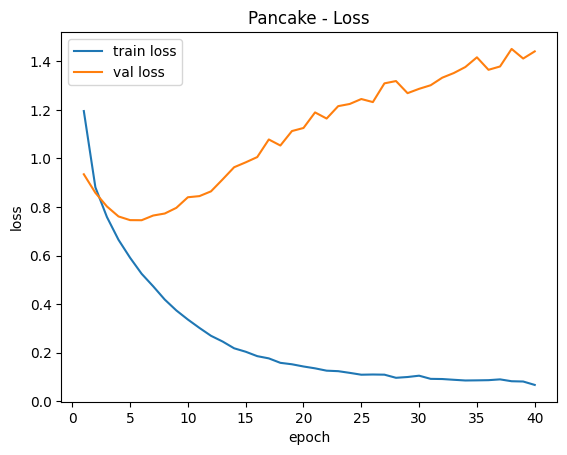

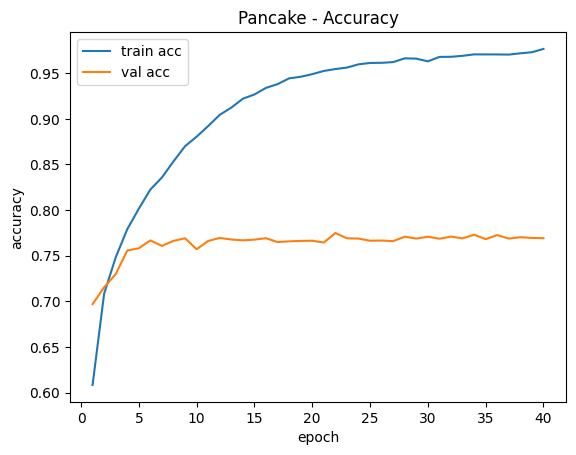

<All keys matched successfully>

In [31]:
loss_fn = nn.CrossEntropyLoss()

print("\n" + "="*40)
print("TRAINING: PANCAKE")
print("="*40)

pancake_optimizer = optim.Adam(pancake_model.parameters(), lr=1e-3, weight_decay=0.00)

pancake_history, pancake_best = fit(
    pancake_model,
    train_loader,
    val_loader,
    pancake_optimizer,
    loss_fn,
    DEVICE,
    epochs=EPOCHS,
    scheduler=None,
    verbose=True,
    log_every=5
)


print("\n" + "-"*40)
print(
    f"BEST PANCAKE CHECKPOINT -> "
    f"val acc: {pancake_best['val_acc']:.4f} | "
    f"val loss: {pancake_best['val_loss']:.4f} | "
    f"epoch: {pancake_best['epoch']}"
)
print("-"*40)

plot_history(pancake_history, title="Pancake")

pancake_model.load_state_dict(pancake_best["state_dict"])


TRAINING: TOWER
Epoch 01/40 | train loss 1.0461 acc 0.6520 | val loss 0.8645 acc 0.7070 | lr 1.000e-03
Epoch 05/40 | train loss 0.5435 acc 0.8179 | val loss 0.7326 acc 0.7662 | lr 1.000e-03
Epoch 10/40 | train loss 0.3276 acc 0.8884 | val loss 0.8176 acc 0.7627 | lr 1.000e-03
Epoch 15/40 | train loss 0.2071 acc 0.9287 | val loss 0.9779 acc 0.7590 | lr 1.000e-03
Epoch 20/40 | train loss 0.1419 acc 0.9502 | val loss 1.1344 acc 0.7586 | lr 1.000e-03
Epoch 25/40 | train loss 0.1011 acc 0.9655 | val loss 1.2465 acc 0.7606 | lr 1.000e-03
Epoch 30/40 | train loss 0.0790 acc 0.9729 | val loss 1.3551 acc 0.7603 | lr 1.000e-03
Epoch 35/40 | train loss 0.0643 acc 0.9775 | val loss 1.4368 acc 0.7636 | lr 1.000e-03
Epoch 40/40 | train loss 0.0595 acc 0.9796 | val loss 1.4454 acc 0.7598 | lr 1.000e-03

----------------------------------------
BEST Tower CHECKPOINT -> val acc: 0.7714 | val loss: 0.7288 | epoch: 6
----------------------------------------


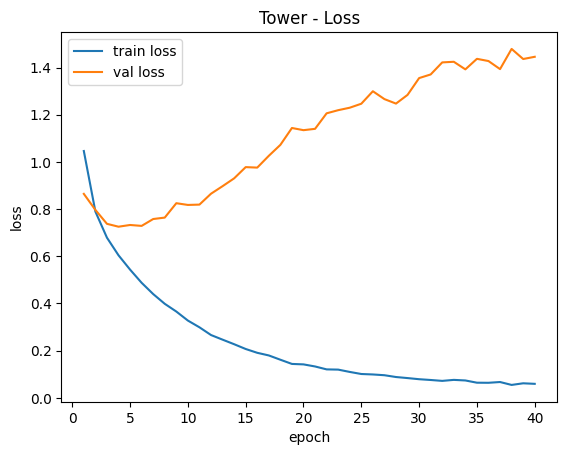

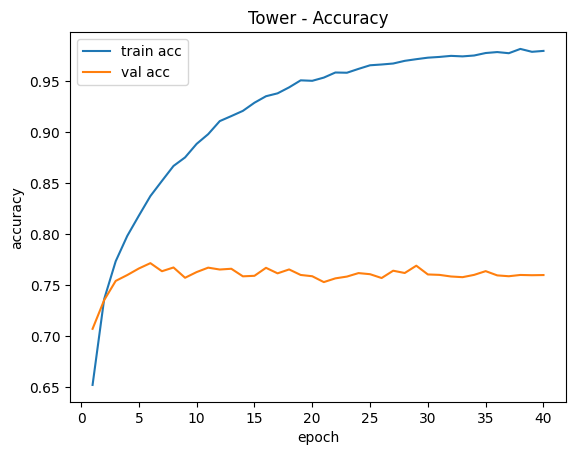

<All keys matched successfully>

In [32]:

print("\n" + "="*40)
print("TRAINING: TOWER")
print("="*40)

tower_optimizer = optim.Adam(tower_model.parameters(), lr=1e-3, weight_decay=0.0)

tower_history, tower_best = fit(
    tower_model,
    train_loader,
    val_loader,
    tower_optimizer,
    loss_fn,
    DEVICE,
    epochs=EPOCHS,
    scheduler=None,
    verbose=True,
    log_every=5
)



print("\n" + "-"*40)
print(
    f"BEST Tower CHECKPOINT -> "
    f"val acc: {tower_best['val_acc']:.4f} | "
    f"val loss: {tower_best['val_loss']:.4f} | "
    f"epoch: {tower_best['epoch']}"
)
print("-"*40)

plot_history(tower_history, title="Tower")

tower_model.load_state_dict(tower_best["state_dict"])


In [33]:
# fit with early stopping 
def fit_early_stop(
    model: torch.nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: torch.nn.Module,
    device: torch.device,
    epochs: int,
    scheduler: Optional[Any] = None,
    scheduler_step_on: str = "epoch",
    verbose: bool = True,
    log_every: int = 5,
    patience: int = 5,         
    min_delta: float = 1e-4,    
    early_stop_on: str = "val_loss",  
):
    model = model.to(device)

    history = History()
    best = {
        "epoch": -1,
        "val_acc": -1.0,
        "val_loss": float("inf"),
        "state_dict": None,
    }

    patience_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
        val_loss, val_acc = validate_one_epoch(model, val_loader, loss_fn, device)

        history.train_loss.append(train_loss)
        history.train_acc.append(train_acc)
        history.val_loss.append(val_loss)
        history.val_acc.append(val_acc)

        improved = (val_acc > best["val_acc"] + min_delta)
        if improved:
            best["epoch"] = epoch
            best["val_acc"] = val_acc
            best["val_loss"] = val_loss
            best["state_dict"] = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
                
        
        
        if scheduler is not None:
            if scheduler_step_on == "val_loss":
                scheduler.step(val_loss)
            else:
                scheduler.step()

        
        if verbose and (epoch == 1 or epoch == epochs or (log_every > 0 and epoch % log_every == 0)):
            lr = _get_current_lr(optimizer)
            lr_str = f"{lr:.3e}" if lr == lr else "n/a"
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {train_loss:.4f} acc {train_acc:.4f} | "
                f"val loss {val_loss:.4f} acc {val_acc:.4f} | "
                f"lr {lr_str} | "
                f"pat {patience_counter}/{patience}"
            )

        
        if patience_counter >= patience:
            if verbose:
                print(f"\nEarly stopping triggered at epoch {epoch} (best epoch: {best['epoch']}).")
            break

    return history, best

In [34]:
champion_model = MLPClassifier(
    input_dim=784,
    num_classes=15,
    hidden_dims=[256, 256, 224,224,192,192],
    activation="gelu",
    dropout_p=0.17,
    use_batchnorm=True,
    use_layernorm=False,
)



TRAINING: CHAMPION
Epoch 01/40 | train loss 1.3723 acc 0.6037 | val loss 1.0983 acc 0.7005 | lr 1.000e-03 | pat 0/10
Epoch 05/40 | train loss 0.9432 acc 0.7662 | val loss 0.9311 acc 0.7666 | lr 1.000e-03 | pat 0/10
Epoch 10/40 | train loss 0.8023 acc 0.8214 | val loss 0.8995 acc 0.7822 | lr 1.000e-03 | pat 1/10
Epoch 15/40 | train loss 0.6629 acc 0.8743 | val loss 0.9003 acc 0.7923 | lr 5.000e-04 | pat 0/10
Epoch 20/40 | train loss 0.5797 acc 0.9074 | val loss 0.9281 acc 0.7937 | lr 1.250e-04 | pat 1/10
Epoch 25/40 | train loss 0.5559 acc 0.9149 | val loss 0.9355 acc 0.7947 | lr 3.125e-05 | pat 3/10
Epoch 30/40 | train loss 0.5447 acc 0.9201 | val loss 0.9405 acc 0.7940 | lr 1.563e-05 | pat 3/10
Epoch 35/40 | train loss 0.5434 acc 0.9203 | val loss 0.9437 acc 0.7955 | lr 3.906e-06 | pat 8/10

Early stopping triggered at epoch 37 (best epoch: 27).

----------------------------------------
BEST Champion CHECKPOINT -> val acc: 0.7955 | val loss: 0.9392 | epoch: 27
-----------------------

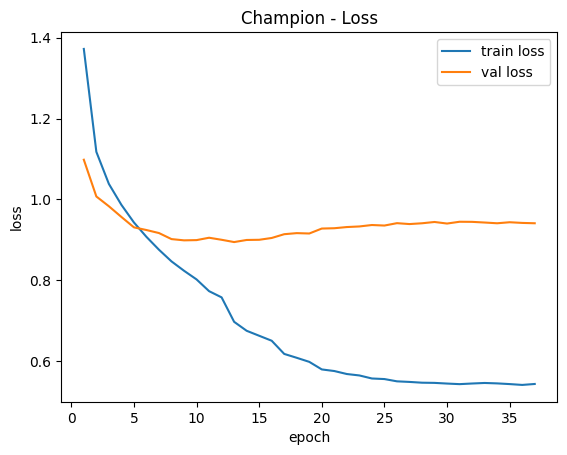

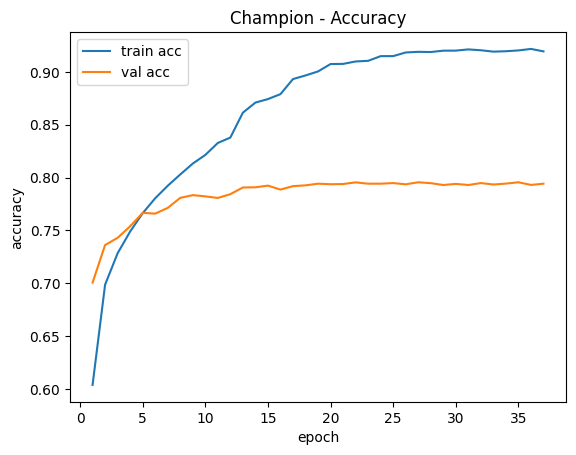

<All keys matched successfully>

In [35]:
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)

print("\n" + "="*40)
print("TRAINING: CHAMPION")
print("="*40)


champion_optimizer = optim.AdamW(champion_model.parameters(), lr=1e-3, weight_decay=1e-4)


champion_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    champion_optimizer,
    mode="min",
    factor=0.5,     
    patience=2,     
    threshold=1e-4,
) 

""" champion_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    champion_optimizer,
    T_max=EPOCHS,
    eta_min=1e-5
) """

champion_history, champion_best = fit_early_stop(
    champion_model,
    train_loader,
    val_loader,
    champion_optimizer,
    loss_fn,
    DEVICE,
    epochs=EPOCHS,
    scheduler=champion_scheduler,
    scheduler_step_on="val_loss",  
    verbose=True,
    log_every=5,
    patience=10,        
    min_delta=1e-5,
    early_stop_on="val_loss"
    
)

print("\n" + "-"*40)
print(
    f"BEST Champion CHECKPOINT -> "
    f"val acc: {champion_best['val_acc']:.4f} | "
    f"val loss: {champion_best['val_loss']:.4f} | "
    f"epoch: {champion_best['epoch']}"
)
print("-"*40)

plot_history(champion_history, title="Champion")

champion_model.load_state_dict(champion_best["state_dict"])


In [36]:

os.makedirs("checkpoints", exist_ok=True)

torch.save(champion_model.state_dict(), "checkpoints/champion_best.pth")

print("saved:", "checkpoints/champion_best.pth", "best epoch:", champion_best["epoch"])

saved: checkpoints/champion_best.pth best epoch: 27


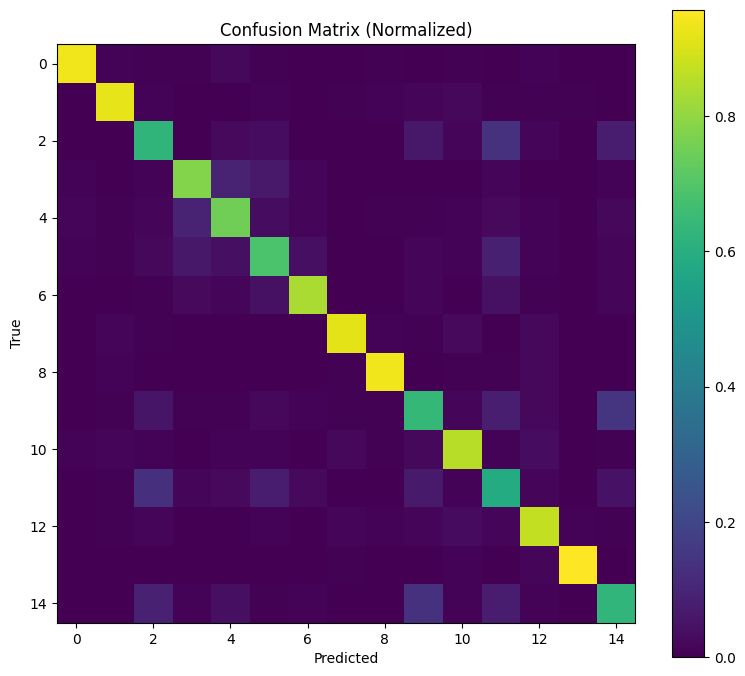

Top 2 confused pairs (true -> predicted, count):
  9 (9)  ->  14 (14) : 116
  2 (2)  ->  11 (11) : 113


In [40]:
# confuson matrix


@torch.no_grad()
def get_val_preds(model, loader, device):
    model.eval()
    all_y = []
    all_p = []
    for x, y in loader:
        x, y = move_to_device(x, y, device)
        logits = model(x)
        preds = torch.argmax(logits, dim=1)
        all_y.append(y.detach().cpu())
        all_p.append(preds.detach().cpu())
    return torch.cat(all_y).numpy(), torch.cat(all_p).numpy()

def confusion_matrix_np(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def top_confused_pairs(cm, topk=2):
    cm_off = cm.copy()
    np.fill_diagonal(cm_off, 0)  
    flat_idx = np.argsort(cm_off.ravel())[::-1]
    pairs = []
    for idx in flat_idx:
        i, j = np.unravel_index(idx, cm_off.shape)
        if cm_off[i, j] == 0:
            break
        pairs.append((i, j, cm_off[i, j]))
        if len(pairs) == topk:
            break
    return pairs

def plot_confusion_matrix(cm, class_names=None, normalize=True, title="Confusion Matrix"):
    cm_plot = cm.astype(np.float32)
    if normalize:
        row_sums = cm_plot.sum(axis=1, keepdims=True) + 1e-12
        cm_plot = cm_plot / row_sums

    plt.figure(figsize=(8, 7))
    plt.imshow(cm_plot, interpolation="nearest")
    plt.title(title + (" (Normalized)" if normalize else ""))
    plt.colorbar()
    if class_names is not None:
        ticks = np.arange(len(class_names))
        plt.xticks(ticks, class_names, rotation=45, ha="right")
        plt.yticks(ticks, class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()



y_true, y_pred = get_val_preds(champion_model, val_loader, DEVICE)

num_classes = 15 
cm = confusion_matrix_np(y_true, y_pred, num_classes=num_classes)

plot_confusion_matrix(cm, class_names=CLASS_NAMES if "CLASS_NAMES" in globals() else None)

pairs = top_confused_pairs(cm, topk=2)
print("Top 2 confused pairs (true -> predicted, count):")
for i, j, c in pairs:
    name_i = CLASS_NAMES[i] if "CLASS_NAMES" in globals() else str(i)
    name_j = CLASS_NAMES[j] if "CLASS_NAMES" in globals() else str(j)
    print(f"  {i} ({name_i})  ->  {j} ({name_j}) : {c}")

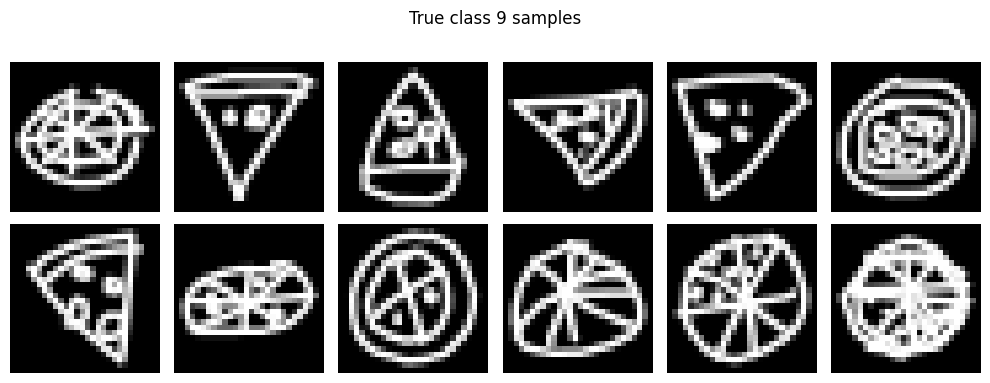

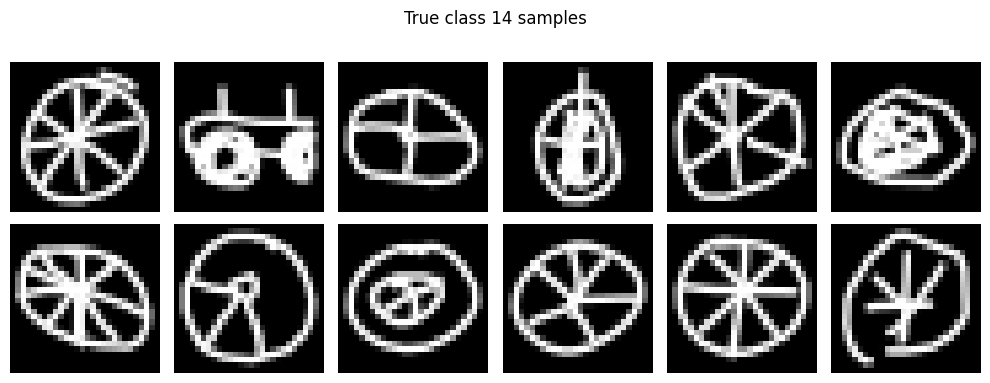

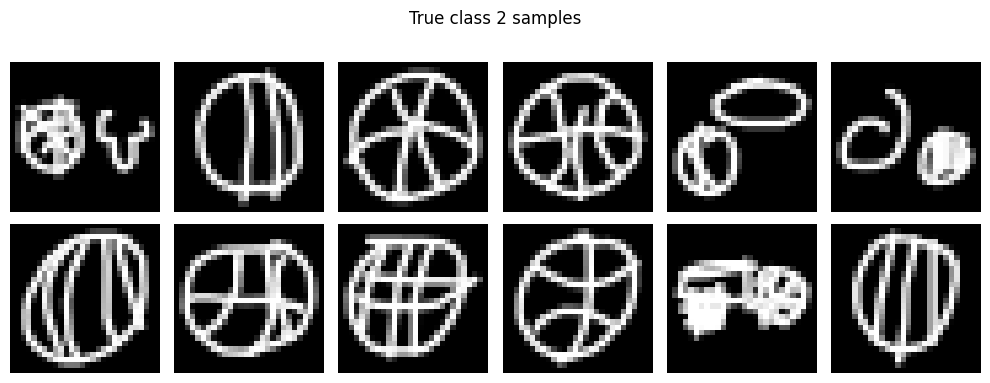

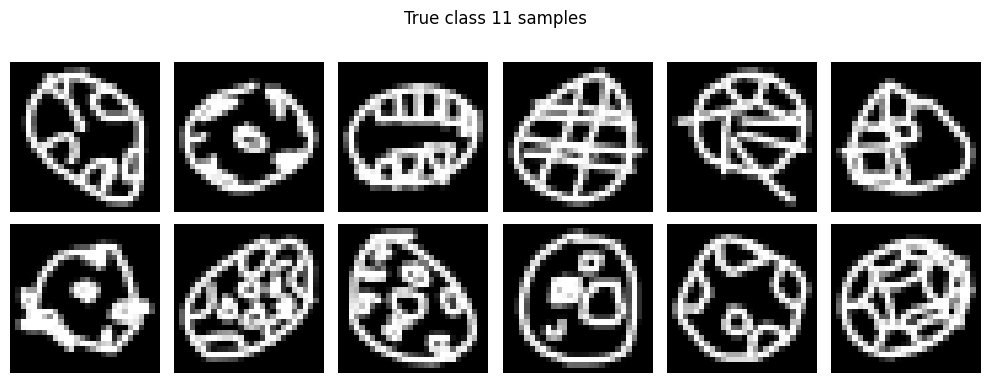

In [41]:

def show_class_samples(loader, class_id, n=12, title=None):
    imgs = []
    for x, y in loader:
        mask = (y == class_id)
        if mask.any():
            imgs.append(x[mask].cpu())
        if sum(t.size(0) for t in imgs) >= n:
            break

    X = torch.cat(imgs, dim=0)[:n]
    if X.ndim == 2 and X.shape[1] == 784:
        X = X.view(-1, 28, 28)
    elif X.ndim == 4:
        X = X[:, 0]

    plt.figure(figsize=(10, 4))
    for i in range(len(X)):
        plt.subplot(2, (len(X)+1)//2, i+1)
        plt.imshow(X[i], cmap="gray")
        plt.axis("off")
    plt.suptitle(title or f"Class {class_id} samples")
    plt.tight_layout()
    plt.show()

show_class_samples(val_loader, 9, n=12, title="True class 9 samples")
show_class_samples(val_loader, 14, n=12, title="True class 14 samples")

show_class_samples(val_loader, 2, n=12, title="True class 2 samples")
show_class_samples(val_loader, 11, n=12, title="True class 11 samples")

In [43]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
model=champion_model

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from ./processed_data\quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [44]:
model = champion_model
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(model)


Model Statistics:
  Total Parameters: 460,559
  ✅ Parameter count is within limits.
